Importing the libraries

In [855]:
import cv2
import numpy as np
import os
import pandas as pd
import random
from matplotlib import pyplot as plt
import itertools

REFERENCE_DIR = "./reference_set"
TARGET_DIR = "./target_set"

Circle detection pipeline variables. The ones which are defined at the moment are the best so far.

In [856]:
BILATERAL_D=7
BILATERAL_SIGMACOLOR=85
BILATERAL_SIGMASPACE=85
MEDIAN_KSIZE=11
CLAHE_CLIPLIMIT=1.25
CLAHE_TILEGRIDSIZE=(8, 8)
GAUSSIAN_KSIZE=(5, 5)
GAUSSIAN_SIGMAX=1.5
HOUGH_DP=1
HOUGH_MINDIST=75
HOUGH_PARAM1=80
HOUGH_PARAM2=33
HOUGH_MINRADIUS=36
HOUGH_MAXRADIUS=155
INNER_CIRCLE_MARGINE=16
OVERLAP_THRESHOLD = 0.6

In [857]:
def filter_overlapping_circles(circles, overlap_threshold):
    """
    Remove duplicate circles detected on the same coin.
    Keeps one circle when centers are close and radii are similar.
    """

    if circles is None:
        return None

    circles = np.round(circles[0]).astype(np.int32)

    selected_circles = []

    for circle in circles:
        x1, y1, r1 = circle

        duplicate = False

        for selected in selected_circles:
            x2, y2, r2 = selected

            distance = np.sqrt(
                float((x1 - x2) ** 2 + (y1 - y2) ** 2)
            )

            radius_difference = abs(r1 - r2)

            # Same coin if centers are close
            # and radii are not extremely different
            if (
                distance < overlap_threshold * max(r1, r2)
                and radius_difference < 0.35 * max(r1, r2)
            ):
                duplicate = True
                break

        if not duplicate:
            selected_circles.append(circle)

    if len(selected_circles) == 0:
        return None

    return np.array([selected_circles], dtype=np.uint16)

In [858]:
def remove_inner_circles(circles, margin):
    """
    Removes circles that are inside larger circles.
    Useful when Hough detects multiple nested circles on the same coin.
    """

    if circles is None:
        return None

    circles = np.round(circles[0]).astype(np.int32)

    keep_circles = []

    for i, c1 in enumerate(circles):
        x1, y1, r1 = c1
        inside_another = False

        for j, c2 in enumerate(circles):
            if i == j:
                continue

            x2, y2, r2 = c2

            # Only compare against larger circles
            if r2 <= r1:
                continue

            distance = np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

            # If the smaller circle is inside the larger circle
            if distance + r1 <= r2 + margin:
                inside_another = True
                break

        if not inside_another:
            keep_circles.append(c1)

    if len(keep_circles) == 0:
        return None

    return np.array([keep_circles], dtype=np.uint16)

In [ ]:
def detect_circles(
    image_path,
    bilateral_d=BILATERAL_D,
    bilateral_sigmaColor=BILATERAL_SIGMACOLOR,
    bilateral_sigmaSpace=BILATERAL_SIGMASPACE,
    median_ksize=MEDIAN_KSIZE,
    clahe_clipLimit=CLAHE_CLIPLIMIT,
    clahe_tileGridSize=CLAHE_TILEGRIDSIZE,
    gaussian_ksize=GAUSSIAN_KSIZE,
    gaussian_sigmaX=GAUSSIAN_SIGMAX,
    hough_dp=HOUGH_DP,
    hough_minDist=HOUGH_MINDIST,
    hough_param1=HOUGH_PARAM1,
    hough_param2=HOUGH_PARAM2,
    hough_minRadius=HOUGH_MINRADIUS,
    hough_maxRadius=HOUGH_MAXRADIUS,
    inner_circle_margin=INNER_CIRCLE_MARGINE,
    overlapped_circles_threshold=OVERLAP_THRESHOLD
):

    img_color = cv2.imread(image_path)
    
    if img_color is None:
        raise FileNotFoundError(f"OpenCV could not find or open the image at: {image_path}")

    img_gray = cv2.cvtColor(
        img_color,
        cv2.COLOR_BGR2GRAY
    )

    img_gray = cv2.bilateralFilter(
        img_gray,
        d=bilateral_d,
        sigmaColor=bilateral_sigmaColor,
        sigmaSpace=bilateral_sigmaSpace
    )

    # Median filter removes salt-and-pepper noise better
    img_gray = cv2.medianBlur(img_gray, median_ksize)

    # CLAHE improves local contrast
    clahe = cv2.createCLAHE(
        clipLimit=clahe_clipLimit,
        tileGridSize=clahe_tileGridSize
    )

    img_gray = clahe.apply(img_gray)

    # Slight Gaussian smoothing
    img_gray = cv2.GaussianBlur(
        img_gray, 
        gaussian_ksize,
        gaussian_sigmaX
    )

    circles = cv2.HoughCircles(
        img_gray,
        cv2.HOUGH_GRADIENT,
        dp=hough_dp,
        minDist=hough_minDist,
        param1=hough_param1,
        param2=hough_param2,
        minRadius=hough_minRadius,
        maxRadius=hough_maxRadius
    )

    # Remove duplicate overlapping circles
    circles = filter_overlapping_circles(circles, overlap_threshold=overlapped_circles_threshold)
    circles = remove_inner_circles(circles, margin=inner_circle_margin)

    combined_mask = np.zeros_like(img_gray)

    if circles is not None:

        circles = np.uint16(np.around(circles))

        for circle in circles[0]:

            x, y, r = circle

            cv2.circle(
                combined_mask,
                (x, y),
                r,
                255,
                -1
            )

    return (
            img_color,      # Original unmodified BGR image used as a visual baseline
            img_gray,       # Fully pre-processed grayscale image (filtered and contrast-enhanced)
            combined_mask,  # Binary mask image (white/255 for detected coins, black/0 for background)
            circles         # NumPy array of (x, y, radius) coordinates for all validated coins
        )


In [872]:
def visualize_preprocessing_steps(
    image_name,
    target_dir=TARGET_DIR,
    bilateral_d=BILATERAL_D,
    bilateral_sigmaColor=BILATERAL_SIGMACOLOR,
    bilateral_sigmaSpace=BILATERAL_SIGMASPACE,
    median_ksize=MEDIAN_KSIZE,
    clahe_clipLimit=CLAHE_CLIPLIMIT,
    clahe_tileGridSize=CLAHE_TILEGRIDSIZE,
    gaussian_ksize=GAUSSIAN_KSIZE,
    gaussian_sigmaX=GAUSSIAN_SIGMAX
):
    # Constructing the full image path
    image_path = os.path.join(target_dir, image_name)
    
    img_color = cv2.imread(image_path)
    if img_color is None:
        raise FileNotFoundError(f"OpenCV could not find or open the image at: {image_path}")

    # 1. Original (Convert BGR to RGB for accurate Matplotlib color rendering)
    img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)

    # 2. Grayscale Conversion
    img_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

    # 3. Bilateral Filter
    img_bilateral = cv2.bilateralFilter(
        img_gray, 
        d=bilateral_d, 
        sigmaColor=bilateral_sigmaColor, 
        sigmaSpace=bilateral_sigmaSpace
    )

    # 4. Median Blur
    img_median = cv2.medianBlur(img_bilateral, median_ksize)

    # 5. CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(
        clipLimit=clahe_clipLimit, 
        tileGridSize=clahe_tileGridSize
    )
    img_clahe = clahe.apply(img_median)

    # 6. Gaussian Smoothing
    img_gaussian = cv2.GaussianBlur(
        img_clahe, 
        gaussian_ksize, 
        gaussian_sigmaX
    )

    # Store steps in a list for clean iterative plotting
    steps = [
        ("1. Original RGB", img_rgb),
        ("2. Grayscale", img_gray),
        ("3. Bilateral Filter", img_bilateral),
        ("4. Median Blur", img_median),
        ("5. CLAHE (Contrast)", img_clahe),
        ("6. Gaussian Smoothing", img_gaussian)
    ]

    # Generate a 2x3 grid of subplots
    plt.figure(figsize=(18, 10))
    for i, (title, img) in enumerate(steps):
        plt.subplot(2, 3, i + 1)
        
        # Display grayscale images properly
        if len(img.shape) == 2:
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(img)
            
        plt.title(title, fontsize=14, pad=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

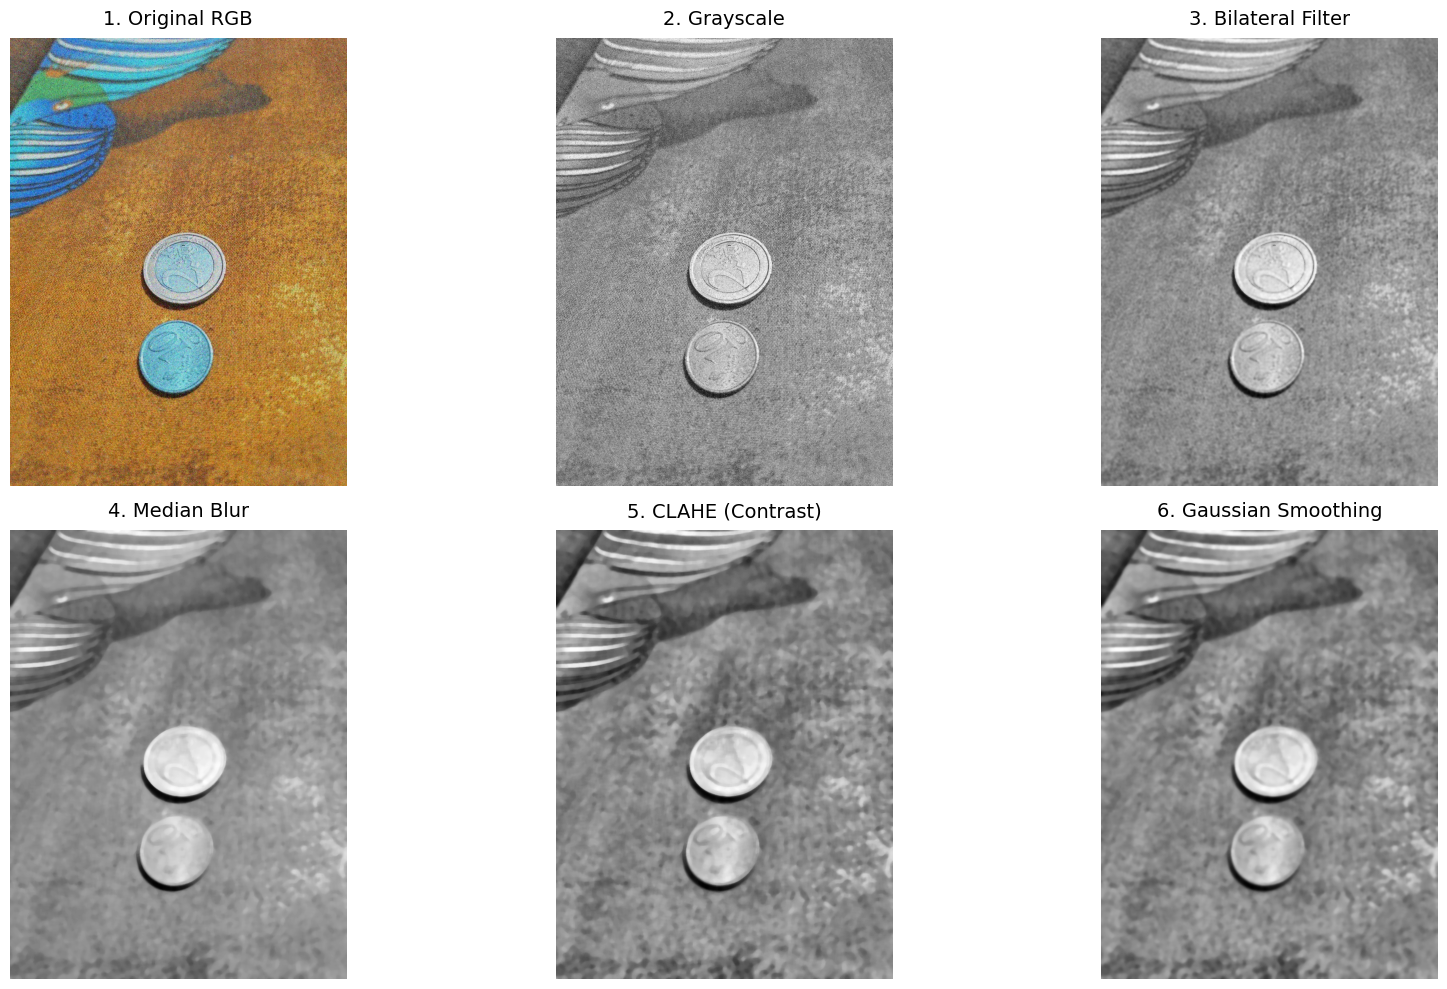

In [873]:
visualize_preprocessing_steps("image_136.jpg")

In [ ]:
def visualize_target_circles_detected(image_name, target_dir=TARGET_DIR):
    # Constructing the full image path
    image_path = os.path.join(target_dir, image_name)
    
    img_color, _, _, circles = detect_circles(image_path)

    img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
    circle_vis = img_rgb.copy()

    if circles is not None:
        for circle in circles[0]:
            x, y, r = circle
            cv2.circle(circle_vis, (x, y), int(r), (0, 255, 0), 3)
            cv2.circle(circle_vis, (x, y), 4, (255, 0, 0), -1)

    plt.imshow(circle_vis)
    # The image name is now easily accessible for the title
    plt.title(f"Detected Coin Regions for image {image_name}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [861]:
def process_and_save_all_images(target_dir, output_dir_name="visualized_pipeline_results"):
    """
    Creates a folder in the current directory, processes all images in target_dir, 
    and saves the plots without altering the main visualization function.
    """
    current_dir = os.getcwd()
    save_dir = os.path.join(current_dir, output_dir_name)
    os.makedirs(save_dir, exist_ok=True)
    
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif')
    image_files = [f for f in os.listdir(target_dir) if f.lower().endswith(valid_extensions)]
    
    for image_name in image_files:
        image_path = os.path.join(target_dir, image_name)
        img_color, denoised, combined_mask, circles = detect_circles(image_path)

        img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
        circle_vis = img_rgb.copy()

        if circles is not None:
            for circle in circles[0]:
                x, y, r = circle
                cv2.circle(circle_vis, (x, y), int(r), (0, 255, 0), 3)
                cv2.circle(circle_vis, (x, y), 4, (255, 0, 0), -1)

        plt.figure(figsize=(8, 6))
        plt.imshow(circle_vis)
        plt.title(f"Detected Coin Regions for image {image_name}")
        plt.axis("off")
        plt.tight_layout()
        
        # Save and close to prevent memory leaks from displaying multiple plots
        save_path = os.path.join(save_dir, image_name)
        plt.savefig(save_path, bbox_inches='tight')
        plt.close()
        
    print(f"Successfully processed {len(image_files)} images and saved them to {save_dir}")

Run this function below to create all the target images with their circles detected.

In [862]:
# process_and_save_all_images(target_dir=TARGET_DIR)

Visualizing the specific image circle (coin) detection.

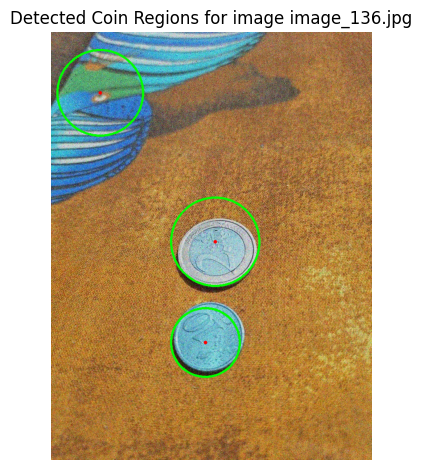

In [863]:
visualize_target_circles_detected("image_136.jpg")

Detection accuracy computation :

In [864]:
def compare_detected_vs_actual(target_dir, csv_path):
    ground_truth = pd.read_csv(csv_path)

    # FIXED: The first column is named "Image", not "Unnamed: 0"
    ground_truth = ground_truth.rename(columns={
        "Image": "image_name",
        "Total Number of Coins": "actual_num_circles"
    })

    results = []

    for filename in os.listdir(target_dir):
        if not filename.lower().endswith(".jpg"):
            continue

        image_path = os.path.join(target_dir, filename)

        (
            img_color,
            denoised,
            combined_mask,
            circles
        ) = detect_circles(image_path)

        if circles is not None:
            detected_num_circles = len(circles[0])
        else:
            detected_num_circles = 0

        image_id = filename.replace(".jpg", "")

        actual_row = ground_truth[ground_truth["image_name"] == image_id]

        if len(actual_row) == 0:
            actual_num_circles = None
        else:
            actual_num_circles = int(actual_row["actual_num_circles"].values[0])

        results.append({
            "image_name": image_id,
            "actual_num_circles": actual_num_circles,
            "detected_num_circles": detected_num_circles,
            "difference": None if actual_num_circles is None else detected_num_circles - actual_num_circles,
            "correct": None if actual_num_circles is None else detected_num_circles == actual_num_circles
        })

    comparison_df = pd.DataFrame(results)

    return comparison_df

In [865]:
comparison_df = compare_detected_vs_actual(
    target_dir="./target_set",
    csv_path="./Coin values assignment.csv"
)

img_circle_detection_accuracy = comparison_df["correct"].mean()
total_num_diff_extra = comparison_df["difference"][comparison_df["difference"] > 0].sum()
total_num_diff_missing = comparison_df["difference"][comparison_df["difference"] < 0].sum()
total_zero_circle_detected = comparison_df.loc[comparison_df["detected_num_circles"] == 0].shape[0]

total_absolute_error = comparison_df["difference"].abs().sum()
total_actual_coins = comparison_df["actual_num_circles"].sum()
total_coin_detection_accuracy = max(0, 1 - (total_absolute_error / total_actual_coins))

print(f"Total number of images without any cicle detected : {total_zero_circle_detected}")
print(f"Total false positive detections : {total_num_diff_extra}")
print(f"Total number of not detected circles : {abs(total_num_diff_missing)}")
print(f"Accuracy over detecting the actual number of cicles over total number of coins : {total_coin_detection_accuracy:.2%}")
print(f"Accuracy over detecting the actual number of cicles over images exactly : {img_circle_detection_accuracy:.2%}")

Total number of images without any cicle detected : 0
Total false positive detections : 2
Total number of not detected circles : 3
Accuracy over detecting the actual number of cicles over total number of coins : 98.48%
Accuracy over detecting the actual number of cicles over images exactly : 96.48%


In [866]:
incorrect_detections = comparison_df[comparison_df["difference"] != 0]
incorrect_detections.sort_values("difference")

,image_name,actual_num_circles,detected_num_circles,difference,correct
24,image_120,2,1,-1,False
63,image_28,2,1,-1,False
93,image_55,2,1,-1,False
41,image_136,2,3,1,False
62,image_27,5,6,1,False


# Tuning the parameters

Input the hyper parameter that you want to tune in the dictionary below running the grid search.

In [867]:
PARAM_GRID = {

    "hough_minDist": list(range(7, 15, 1))

    # Test strict vs relaxed circle detection
    # "hough_minRadius": list(range(30, 40, 1)),
    
    # Test different edge sensitivities
    # "hough_maxRadius": list(range(150, 160, 1)),
    
    # # Test aggressive vs light noise removal (must be odd numbers)
    # "median_ksize": [5, 7, 11],
    
    # # Test different bilateral blur diameters
    # "bilateral_d": [5, 7, 9]
}


In [868]:
def evaluate_pipeline(target_dir, ground_truth, params):
    """Runs the pipeline for a single set of parameters and returns metrics."""
    results = []
    
    for filename in os.listdir(target_dir):
        if not filename.lower().endswith(".jpg"):
            continue

        image_path = os.path.join(target_dir, filename)
        _, _, _, circles = detect_circles(image_path, **params)
        
        detected_num = len(circles[0]) if circles is not None else 0
        image_id = filename.replace(".jpg", "")
        actual_row = ground_truth[ground_truth["image_name"] == image_id]
        
        if len(actual_row) > 0:
            actual_num = int(actual_row["actual_num_circles"].values[0])
            results.append({"actual": actual_num, "detected": detected_num})
            
    df = pd.DataFrame(results)
    if df.empty:
        return 0, 0, 0, 0
        
    df["difference"] = df["detected"] - df["actual"]
    
    missing_circles = abs(df[df["difference"] < 0]["difference"].sum())
    false_positives = df[df["difference"] > 0]["difference"].sum()

    exact_matches = len(df[df["difference"] == 0])
    image_accuracy = exact_matches / len(df)
    
    total_error = df["difference"].abs().sum()
    total_actual = df["actual"].sum()
    coin_accuracy = max(0, 1 - (total_error / total_actual)) if total_actual > 0 else 0
    
    return missing_circles, false_positives, image_accuracy, coin_accuracy


def run_grid_search(target_dir, csv_path, param_grid, output_csv="grid_search_results.csv"):
    """Iterates through all parameter combinations, tracks the best result, and saves all metrics to a CSV."""
    ground_truth = pd.read_csv(csv_path)
    ground_truth = ground_truth.rename(columns={
        "Image": "image_name",
        "Total Number of Coins": "actual_num_circles"
    })
    
    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    print(f"Starting Grid Search: Testing {len(combinations)} combinations...\n")
    
    best_image_acc = 0
    best_params = None
    all_results = []
    
    for i, params in enumerate(combinations, 1):
        # UPDATED: Unpack false_positives from evaluate_pipeline
        missing, false_positives, image_acc, coin_acc = evaluate_pipeline(target_dir, ground_truth, params)
        
        current_result = params.copy()
        current_result["missing_circles"] = missing
        # UPDATED: Add false_positives to the results saved to CSV
        current_result["false_positives"] = false_positives 
        current_result["image_accuracy"] = image_acc
        current_result["coin_accuracy"] = coin_acc
        all_results.append(current_result)
        
        if i % 10 == 0:
            print(f"Progress: {i}/{len(combinations)} combinations tested.")
        
        if image_acc > best_image_acc:
            best_image_acc = image_acc
            best_params = params
            print(f"--> NEW BEST! Image Acc: {image_acc*100:.2f}% | Coin Acc: {coin_acc*100:.2f}% | Missing: {missing} | False Positives: {false_positives}")
            print(f"    Params: {params}\n")
            
    results_df = pd.DataFrame(all_results)
    results_df.to_csv(output_csv, index=False)
    print(f"\nSaved all grid search results to '{output_csv}'")
            
    print("\n=== Grid Search Complete ===")
    print(f"Best Image Accuracy: {best_image_acc*100:.2f}%")
    print(f"Optimal Parameters: {best_params}")
    
    return best_params

Run to see the changes based on the parameters change applied by parameter grid in csv file which gets generated.

In [ ]:
optimal_hyperparameters = run_grid_search(
    target_dir="./target_set", 
    csv_path="./Coin values assignment.csv", 
    param_grid=PARAM_GRID,
    output_csv="tuning_session_2.csv"
)

# IGNORE


This is the pipeline I made to detect based on color + template match which didnt work well (best so far was 44 percent I guess)

In [ ]:
# def visualize_number_based_coin_detection(image_path, templates, min_score=0.15):
#     img_color, detections = detect_and_classify_coins_by_number(
#         image_path,
#         templates,
#         min_score=min_score
#     )

#     img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
#     vis = img_rgb.copy()

#     for det in detections:
#         x = det["x"]
#         y = det["y"]
#         r = det["r"]
#         label = det["coin_value"]
#         score = det["template_score"]

#         cv2.circle(vis, (x, y), r, (0, 255, 0), 3)
#         cv2.circle(vis, (x, y), 3, (255, 0, 0), -1)

#         cv2.putText(
#             vis,
#             f"{label} {score:.2f}",
#             (x - r, y - r - 5),
#             cv2.FONT_HERSHEY_SIMPLEX,
#             0.6,
#             (255, 0, 0),
#             2
#         )

#     plt.figure(figsize=(10, 10))
#     plt.imshow(vis)
#     plt.axis("off")
#     plt.title(f"Detected coins: {len(detections)}")
#     plt.show()

#     return detections

In [ ]:
# templates = build_coin_templates("./reference_set")

# detections = visualize_number_based_coin_detection(
#     "./target_set/image_1.jpg",
#     templates,
#     min_score=0.15
# )

# detections

In [ ]:
# def compare_number_template_vs_actual(target_dir, csv_path, templates, min_score=0.15):
#     ground_truth = pd.read_csv(csv_path)

#     ground_truth = ground_truth.rename(columns={
#         "Unnamed: 0": "image_name",
#         "Total Number of Coins": "actual_num_circles"
#     })

#     results = []

#     for filename in os.listdir(target_dir):

#         if not filename.lower().endswith(".jpg"):
#             continue

#         image_path = os.path.join(target_dir, filename)

#         _, detections = detect_and_classify_coins_by_number(
#             image_path,
#             templates,
#             min_score=min_score
#         )

#         image_id = filename.replace(".jpg", "")

#         actual_row = ground_truth[ground_truth["image_name"] == image_id]

#         if len(actual_row) == 0:
#             actual_num_circles = None
#         else:
#             actual_num_circles = int(actual_row["actual_num_circles"].values[0])

#         detected_num_circles = len(detections)

#         results.append({
#             "image_name": image_id,
#             "actual_num_circles": actual_num_circles,
#             "detected_num_circles": detected_num_circles,
#             "difference": None if actual_num_circles is None else detected_num_circles - actual_num_circles,
#             "correct": None if actual_num_circles is None else detected_num_circles == actual_num_circles,
#             "detected_coin_values": [d["coin_value"] for d in detections]
#         })

#     return pd.DataFrame(results)

In [ ]:
# number_template_df = compare_number_template_vs_actual(
#     "./target_set",
#     "./Coin values assignment.csv",
#     templates,
#     min_score=0.15
# )

# accuracy = number_template_df["correct"].mean() * 100

# print(f"Number-template detection accuracy: {accuracy:.2f}%")

# number_template_df

In [ ]:
# from collections import Counter
# import pandas as pd
# import os


# def coin_label_to_cent(label):
#     label = str(label).lower().replace(" ", "")

#     mapping = {
#         "1cent": 1,
#         "2cent": 2,
#         "5cent": 5,
#         "10cent": 10,
#         "20cent": 20,
#         "50cent": 50,
#         "1euro": 100,
#         "2euro": 200
#     }

#     return mapping.get(label, None)


# def parse_actual_composition(composition_text):
#     if pd.isna(composition_text):
#         return []

#     return [
#         int(x.strip())
#         for x in str(composition_text).split(",")
#         if x.strip() != ""
#     ]


# def compare_detected_values_vs_actual(target_dir, csv_path, templates, min_score=0.15):
#     ground_truth = pd.read_csv(csv_path)

#     ground_truth = ground_truth.rename(columns={
#         "Unnamed: 0": "image_name",
#         "Composition of coins (in cent)": "actual_composition",
#         "Total sum (in cent)": "actual_total_sum",
#         "Total Number of Coins": "actual_num_coins"
#     })

#     results = []

#     for filename in os.listdir(target_dir):

#         if not filename.lower().endswith(".jpg"):
#             continue

#         image_path = os.path.join(target_dir, filename)
#         image_id = filename.replace(".jpg", "")

#         actual_row = ground_truth[ground_truth["image_name"] == image_id]

#         if len(actual_row) == 0:
#             continue

#         actual_values = parse_actual_composition(
#             actual_row["actual_composition"].values[0]
#         )

#         _, detections = detect_and_classify_coins_by_number(
#             image_path,
#             templates,
#             min_score=min_score
#         )

#         detected_values = [
#             coin_label_to_cent(d["coin_value"])
#             for d in detections
#         ]

#         detected_values = [
#             v for v in detected_values
#             if v is not None
#         ]

#         actual_counter = Counter(actual_values)
#         detected_counter = Counter(detected_values)

#         exact_composition_correct = actual_counter == detected_counter

#         actual_sum = sum(actual_values)
#         detected_sum = sum(detected_values)

#         actual_num = len(actual_values)
#         detected_num = len(detected_values)

#         correctly_matched_coins = sum(
#             min(actual_counter[value], detected_counter[value])
#             for value in actual_counter
#         )

#         coin_value_accuracy = correctly_matched_coins / actual_num if actual_num > 0 else 0

#         results.append({
#             "image_name": image_id,

#             "actual_values": sorted(actual_values),
#             "detected_values": sorted(detected_values),

#             "actual_num_coins": actual_num,
#             "detected_num_coins": detected_num,

#             "actual_sum": actual_sum,
#             "detected_sum": detected_sum,

#             "exact_composition_correct": exact_composition_correct,
#             "sum_correct": actual_sum == detected_sum,
#             "count_correct": actual_num == detected_num,

#             "correctly_matched_coins": correctly_matched_coins,
#             "coin_value_accuracy": coin_value_accuracy
#         })

#     results_df = pd.DataFrame(results)

#     return results_df

In [ ]:
# value_comparison_df = compare_detected_values_vs_actual(
#     target_dir="./target_set",
#     csv_path="./Coin values assignment.csv",
#     templates=templates,
#     min_score=0.15
# )

# exact_accuracy = value_comparison_df["exact_composition_correct"].mean() * 100
# sum_accuracy = value_comparison_df["sum_correct"].mean() * 100
# count_accuracy = value_comparison_df["count_correct"].mean() * 100
# average_coin_value_accuracy = value_comparison_df["coin_value_accuracy"].mean() * 100

# print(f"Exact composition accuracy: {exact_accuracy:.2f}%")
# print(f"Total sum accuracy: {sum_accuracy:.2f}%")
# print(f"Coin count accuracy: {count_accuracy:.2f}%")
# print(f"Average coin-value accuracy: {average_coin_value_accuracy:.2f}%")

# value_comparison_df